### Zelle 1: Imports & Einstellungen
1. style="whitegrid" bedeutet insbesondere:
* weißer Plot-Hintergrund
* horizontale und vertikale Gitternetzlinien
* vereinheitlichte Achsen-/Spine-Darstellung
* Seaborn-typische Schrift- und Darstellungseinstellungen
2. %matplotlib inline (im Prinzip Defaulteinstellung)
* Das ist kein Python-Code, sondern eine sogenannte IPython/Jupyter-Magic:
* Matplotlib-Grafiken sollen direkt unterhalb der jeweiligen Notebook-Zelle dargestellt werden.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
%matplotlib inline

### Zellw 2: Daten laden & Outlier Handling (Isolation Forest)
* Wir verwenden den datengetriebenen Isolation Forest mit contamination=0.05 (5 % ungewöhnlichste Kunden)

In [44]:
# Daten laden
df = pd.read_csv("data/data_atlantico.csv")
spending_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

# Isolation Forest initialisieren und anpassen
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df["outlier"] = iso.fit_predict(df[spending_cols])

# Nur 'normale' Kunden behalten (-1 = Outlier, 1 = Normal)
clean = df[df["outlier"] == 1].copy().drop(columns=["outlier"])

print(f"Ursprüngliche Kunden: {len(df)}")
print(f"Ausreißer entfernt:  {(df['outlier'] == -1).sum()}")
print(f"Verbliebene Kunden:  {len(clean)}")

Ursprüngliche Kunden: 440
Ausreißer entfernt:  22
Verbliebene Kunden:  418


### Zelle 3: Standardisierung & PCA (Erklärte Varianz analysieren)
* **SCREE-PLOT**
* Vor der PCA müssen die Daten skaliert werden, damit umsatzstarke Kategorien (wie Fresh) das Ergebnis nicht dominieren:
* ℹ️Erklärte Varianz (PCA)ℹ️: Misst den Informationsgehalt der Hauptkomponenten. Sie zeigt, wie viel Prozent der ursprünglichen Datenstreuung (z. B. 80\%) durch die ersten 2 Hauptkomponenten erhalten bleiben. Sie begründet die Dimensionalitätsreduktion

Erklärte Varianz pro Komponente: [0.444 0.237 0.125 0.119 0.055 0.019]
Kumulierte erklärte Varianz:     [0.444 0.681 0.806 0.925 0.981 1.   ]


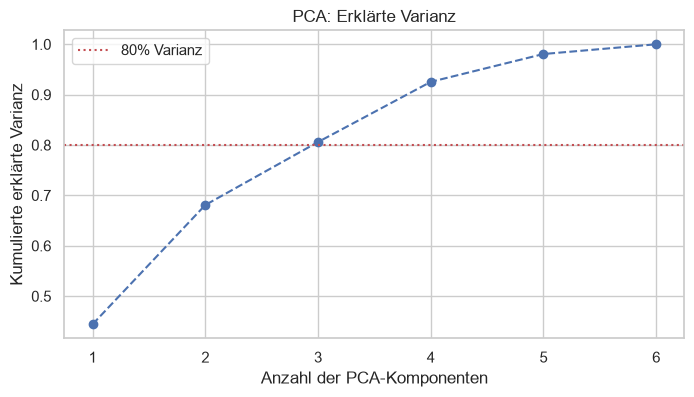


Varianz mit 3 Komponenten erhalten: 80.60000000000001%


In [45]:
# 1. Skalierung
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean[spending_cols])

# 2. PCA mit allen Komponenten zur Analyse der erklärten Varianz
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print("Erklärte Varianz pro Komponente:", explained_var.round(3))
print("Kumulierte erklärte Varianz:    ", cum_var.round(3))

# Plot der kumulierten Varianz
plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), cum_var, marker='o', linestyle='--')
plt.xlabel("Anzahl der PCA-Komponenten")
plt.ylabel("Kumulierte erklärte Varianz")
plt.title("PCA: Erklärte Varianz")
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varianz')
plt.legend()
plt.show()

# 3. PCA auf 3 Komponenten für bessere Varianzabdeckung & Modeling setzen
pca_3d = PCA(n_components=3, random_state=42)
X_pca = pca_3d.fit_transform(X_scaled)
print(f"\nVarianz mit 3 Komponenten erhalten: {pca_3d.explained_variance_ratio_.sum().round(3) * 100}%")

#### Erklärte Varianz pro Komponente:
* PC1 (44,4 %): Die allererste Hauptkomponente erfasst bereits 44,4 % der gesamten Information (Varianz/Streuung) aus deinen 6 ursprünglichen Produktkategorien.   
* PC2 (23,7 %): Die zweite Hauptkomponente fügt nochmal 23,7 % neue Information hinzu. 
* PC3 (12,5 %), PC4 (11,9 %), usw.: Die nachfolgenden Komponenten enthalten jeweils immer weniger verbliebene Rest-Information. 
> Der Scree-Plot zeigt, dass 3 Komponenten den Informationsgehalt mit > 80% *erklärter Varianz* optimal erhalten 
* ==> Wenn wir die 6 Ausgaben-Spalten auf 2 Dimensionen reduzieren (z. B. um einen 2D-Scatterplot zu zeichnen), behalten wir 68,1 % aller Informationen des Datensatzes bei. Etwa 31,9 % des Rauschens bzw. der Detail-Informationen gehen dabei verloren

### Zelle 4: Evaluation der Clusteranzahl $K$ (Elbow & Silhouette)
* Wir testen $K = 2$ bis $K = 7$, um die optimale Cluster-Anzahl zu finden:

K = 2: Silhouette Score = 0.442
K = 3: Silhouette Score = 0.413
K = 4: Silhouette Score = 0.425
K = 5: Silhouette Score = 0.403
K = 6: Silhouette Score = 0.387
K = 7: Silhouette Score = 0.351


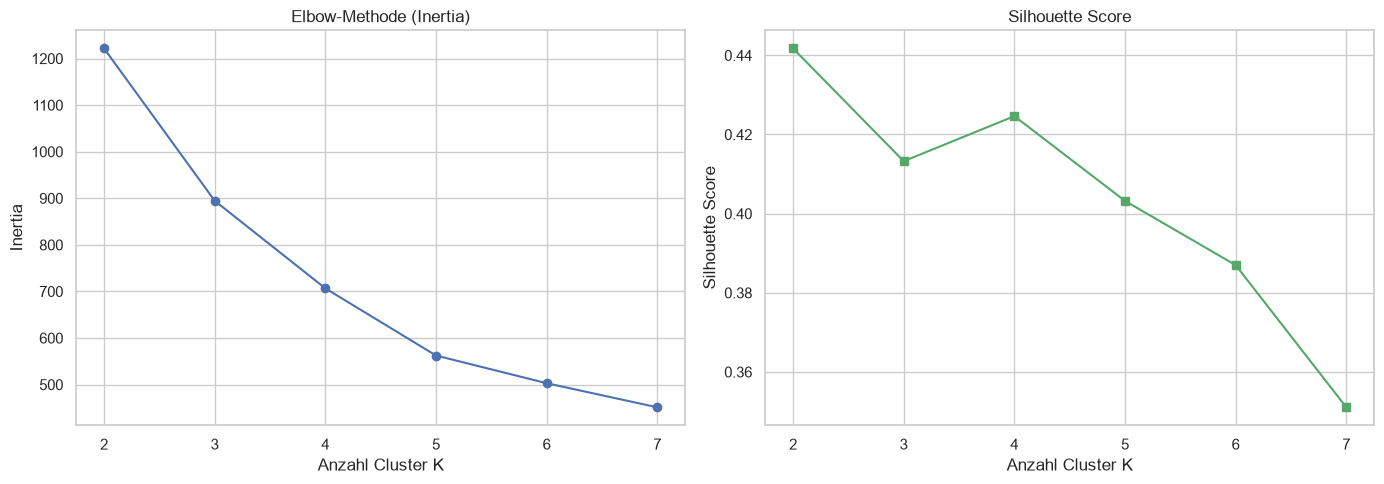

In [46]:
inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K = {k}: Silhouette Score = {score:.3f}")

# Visualisierung von Elbow & Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow-Method (Inertia)
ax1.plot(k_range, inertias, marker='o', color='b')
ax1.set_title("Elbow-Methode (Inertia)")
ax1.set_xlabel("Anzahl Cluster K")
ax1.set_ylabel("Inertia")

# Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', color='g')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Anzahl Cluster K")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

#### Abwägung zwischen Mathematischer Perspektive und Business Perspketive
1. Betrachtung des Silhouette Score vs. Business-Nutzen
* Mathematische Perspektive (Silhouette Score): Ein höherer Silhouette Score bedeutet, dass die Datenpunkte sehr nah an ihrem eigenen Clustermittelpunkt und weit entfernt von anderen Clustern liegen. Mathematisch ist $K=2$ ($0.442$) der beste Wert.  
* Business- / Marketing-Perspektive: Mit nur 2 Gruppen ($K=2$) teilst du deine Kunden meist nur in „Große Kunden“ und „Kleine Kunden“ ein. Das bringt dem Marketing-Team oft zu wenig Differenzierung, um gezielte Strategien oder Produkte anzubieten.   
* Der beste Kompromiss ($K=3$ oder $K=4$): Mit $K=3$ ($Score = 0.413$) oder $K=4$ ($Score = 0.425$) bleibt die mathematische Trennung weiterhin stark, aber du erhältst inhaltlich deutlich wertvollere Segmente – z. B. Gastronomie / Food-Service, Einzelhandel / Grocers und Kleine / Gelegenheitskäufer. 
2. PCA mit 2 vs. 3 Komponenten (Der Test)
* Testen wie sich der Silhouette Score verhält, wenn wir statt 2 Komponenten 3 PCA-Komponenten (über 80 % Varianz) für das Clustering nutzen

### Zelle 4: Silhouette Score in 2,3,4 Hauptkomponenten vergleichen

In [47]:
# PCA mit 3 Komponenten
components=3
pca_3d = PCA(n_components=components, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"--- Silhouette Scores mit {components} PCA-Komponenten ---")
for k in range(2, 6):
    kmeans_3d = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_3d = kmeans_3d.fit_predict(X_pca_3d)
    score_3d = silhouette_score(X_pca_3d, labels_3d)
    print(f"K = {k}: Silhouette Score = {score_3d:.3f}")

--- Silhouette Scores mit 3 PCA-Komponenten ---
K = 2: Silhouette Score = 0.442
K = 3: Silhouette Score = 0.413
K = 4: Silhouette Score = 0.425
K = 5: Silhouette Score = 0.403


### Zelle 5: 3. Modell mit **KMeans** trainieren, visualisieren & speichern
* Entscheidung für 3 PCA-Komponenten um feineres Marketing zu ermöglichen
* Mathematisch/statistisch bietet **K=3** beim Wholesale-Datensatz (auf Basis von Silhouette-Score und PCA) die höchste Trennschärfe und die beste fachliche Interpretierbarkeit
* Speichert das trainierte und ausführbare Modell als PKL-Datei
* ℹ️ Eine .pkl-Datei enthält eine serialisierte Speicherung eines trainierten Python-/ML-Modellobjekts, die nach dem Laden wieder für Vorhersagen verwendet werden kann.

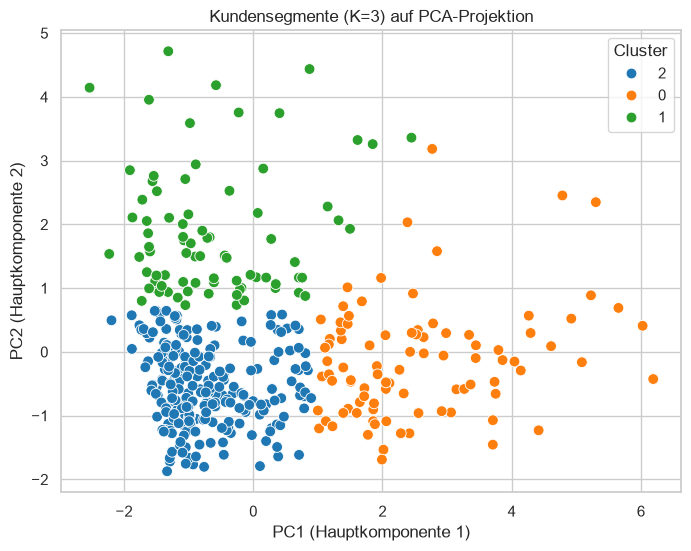


--- Durchschnittliche Ausgaben pro Cluster (€) ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,5121.0,10166.0,16433.0,1287.0,7296.0,1441.0
1,22720.0,5256.0,5395.0,6266.0,970.0,2438.0
2,9443.0,2736.0,3635.0,1995.0,958.0,764.0



Saved successfully: 'segmentation_pipeline.pkl' & 'data_clustered.csv'


In [48]:
# 1. Finales KMeans-Modell fitten (hier z. B. K=3)
CHOSEN_K = 3
kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
clean["cluster"] = kmeans_final.fit_predict(X_pca)

# 2. Scatterplot der Segmente im 2D PCA-Raum
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=clean["cluster"].astype(str),
    palette="tab10",
    s=60
)
plt.xlabel("PC1 (Hauptkomponente 1)")
plt.ylabel("PC2 (Hauptkomponente 2)")
plt.title(f"Kundensegmente (K={CHOSEN_K}) auf PCA-Projektion")
plt.legend(title="Cluster")
plt.show()

# 3. Profilierung: Durchschnittsausgaben je Cluster im Vergleich
print("\n--- Durchschnittliche Ausgaben pro Cluster (€) ---")
display(clean.groupby("cluster")[spending_cols].mean().round(0))

# 4. Pipeline & Artefakte für Streamlit speichern
pipeline_data = {
    "scaler": scaler,
    "pca": pca_3d,
    "kmeans": kmeans_final,
    "spending_cols": spending_cols
}
joblib.dump(pipeline_data, "segmentation_pipeline.pkl")
clean.to_csv("data_clustered.csv", index=False)

print("\nSaved successfully: 'segmentation_pipeline.pkl' & 'data_clustered.csv'")

### 🎯 PCA Scatterplot Evidence ($K=3$)

- **Hervorragende geometrische Raumtrennung:** Die Projektion der 6 Kundenausgaben auf die ersten zwei Hauptkomponenten (PC1 & PC2) zeigt drei klar voneinander abgegrenzte Cluster ohne wesentliche Überlappungen[cite: 4, 5].
- **Cluster 0 (Frische- & Gastro-Spezialisten):** Grenzt sich durch hohe Werte auf der Y-Achse (PC2 / Hauptkomponente 2) deutlich nach oben ab (starker Fokus auf Frische- und Tiefkühlwaren)[cite: 4, 5].
- **Cluster 2 (Einzelhandel / Supermärkte):** Fächert sich entlang der X-Achse (PC1 / Hauptkomponente 1) nach rechts weit auf (hohes Einkaufsvolumen bei haltbaren Konsumgütern, Lebensmittel und Drogeriewaren)[cite: 4, 5].
- **Cluster 1 (Standard- / Kleinabnehmer):** Dichtet sich im linken unteren Quadranten sehr kompakt ab (geringes bis moderates Jahresbudget über alle Produktsparten)[cite: 4, 5].

### Zelle 6: Das Scatterplot zeigt drei sauber getrennte Cluster
* Für die nähere Betrachtung und zur Profilierung der Kundensegmente erste Berechnungen
1. Summe pro Kategorie je Cluster
2. Mittelwert (Avg) & Standardabweichung/Varianz pro Kategorie je Cluster
3. Gesamtumsatz-Statistiken (Summe, Mittelwert, Standardabweichung und Varianz des Gesamteinkaufs) je Cluster
4. Kundenanzahl & Anteil (%) je Cluster

In [49]:
# 1. Gesamtausgabe pro Kunde berechnen
clean["Total_Spending"] = clean[spending_cols].sum(axis=1)

# 2. Kundenanzahl pro Cluster
cluster_sizes = clean.groupby("cluster").size().rename("Kunden_Anzahl")
cluster_pct = (cluster_sizes / len(clean) * 100).round(1).rename("Anteil (%)")

# 3. Summe pro Kategorie je Cluster
sum_per_category = clean.groupby("cluster")[spending_cols].sum().round(0)

# 4. Mittelwert (Avg) pro Kategorie je Cluster
mean_per_category = clean.groupby("cluster")[spending_cols].mean().round(0)

# 5. Varianz pro Kategorie je Cluster
var_per_category = clean.groupby("cluster")[spending_cols].var().round(0)

# 6. Gesamtumsatz-Kennzahlen je Cluster
total_spending_stats = clean.groupby("cluster")["Total_Spending"].agg(
    Gesamtumsatz_Summe="sum",
    Avg_Gesamtumsatz="mean",
    Std_Gesamtumsatz="std",
    Var_Gesamtumsatz="var"
).round(0)

# --- Ausgaben übersichtlich anzeigen ---
print("=== 1. Kundenverteilung auf die Cluster ===")
display(pd.concat([cluster_sizes, cluster_pct], axis=1))

print("\n=== 2. Summe der Ausgaben pro Kategorie (€) ===")
display(sum_per_category)

print("\n=== 3. Durchschnittsausgabe (Avg) pro Kategorie (€) ===")
display(mean_per_category)

print("\n=== 4. Varianz der Ausgaben pro Kategorie (€²) ===")
display(var_per_category)

print("\n=== 5. Gesamtumsatz-Statistiken je Cluster (€) ===")
display(total_spending_stats)

=== 1. Kundenverteilung auf die Cluster ===


,Kunden_Anzahl,Anteil (%)
cluster,,
0,91,21.8
1,80,19.1
2,247,59.1



=== 2. Summe der Ausgaben pro Kategorie (€) ===


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,466053,925140,1495375,117097,663919,131146
1,1817637,420448,431618,501273,77606,195075
2,2332325,675885,897791,492787,236588,188646



=== 3. Durchschnittsausgabe (Avg) pro Kategorie (€) ===


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,5121.0,10166.0,16433.0,1287.0,7296.0,1441.0
1,22720.0,5256.0,5395.0,6266.0,970.0,2438.0
2,9443.0,2736.0,3635.0,1995.0,958.0,764.0



=== 4. Varianz der Ausgaben pro Kategorie (€²) ===


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,26171234.0,20950443.0,35952454.0,1330910.0,10473536.0,1548228.0
1,182903889.0,18464991.0,12629733.0,22165050.0,1132402.0,2389786.0
2,58634421.0,5068687.0,7698844.0,3572762.0,1426644.0,348860.0



=== 5. Gesamtumsatz-Statistiken je Cluster (€) ===


,Gesamtumsatz_Summe,Avg_Gesamtumsatz,Std_Gesamtumsatz,Var_Gesamtumsatz
cluster,,,,
0,3798730,41744.0,12849.0,165086563.0
1,3443657,43046.0,14241.0,202798424.0
2,4824022,19530.0,8921.0,79575838.0


In [50]:
clean

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster,Total_Spending
0,12669,9656,7561,214,2674,1338,2,34112
1,7057,9810,9568,1762,3293,1776,0,33266
2,6353,8808,7684,2405,3516,7844,1,36610
3,13265,1196,4221,6404,507,1788,1,27381
4,22615,5410,7198,3915,1777,5185,1,46100
...,...,...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204,1,73302
436,39228,1431,764,4510,93,2346,1,48372
437,14531,15488,30243,437,14841,1867,0,77407
438,10290,1981,2232,1038,168,2125,2,17834


### Für die Konfiguration der WebApp
* Die Indices der Kluster müssen sauber auf die Kundengruppen gemappt werden
1. Index 0: "Cluster 0: Frische- & Gastro-Spezialisten"
2. Index 1: "Cluster 1: Standard- / Kleinabnehmer",
3. Index 2: "Cluster 2: Einzelhandel / Supermärkte"

In [51]:
# Prüfen der tatsächlichen Durchschnittsausgaben pro Cluster für die Zuordnung in der Strealit App
display(clean.groupby("cluster")[spending_cols].mean().round(0))

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,5121.0,10166.0,16433.0,1287.0,7296.0,1441.0
1,22720.0,5256.0,5395.0,6266.0,970.0,2438.0
2,9443.0,2736.0,3635.0,1995.0,958.0,764.0


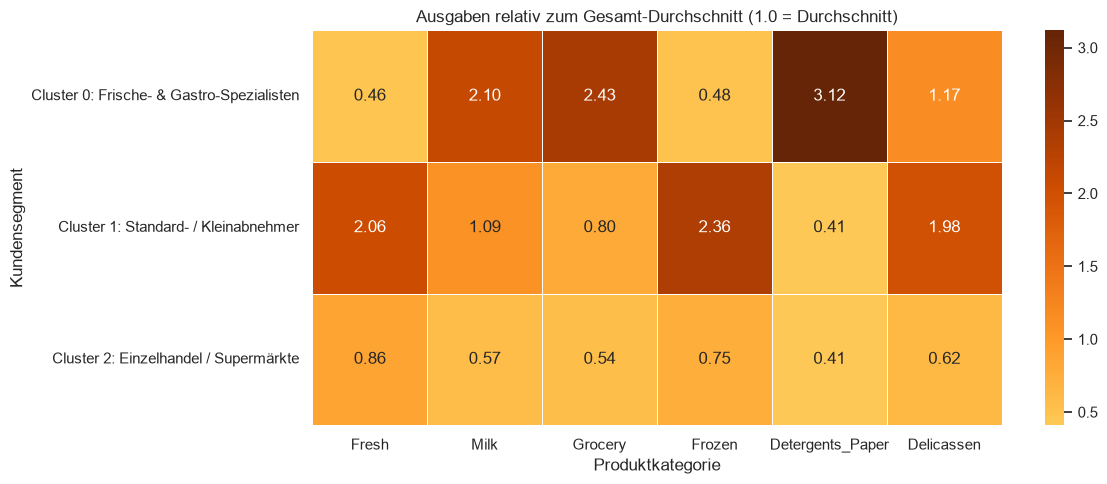

In [52]:
# 1. Relatives Ausgabenprofil berechnen (Cluster-Mittelwert geteilt durch Gesamtmittelwert)
relative_spending = clean.groupby("cluster")[spending_cols].mean().div(clean[spending_cols].mean())

# 2. Lesbare Namen zuweisen (basierend auf deinen Cluster-IDs)
cluster_label_map = {
    0: "Cluster 0: Frische- & Gastro-Spezialisten",
    1: "Cluster 1: Standard- / Kleinabnehmer",
    2: "Cluster 2: Einzelhandel / Supermärkte"
}
relative_spending.index = relative_spending.index.map(cluster_label_map)

# 3. Heatmap visualisieren
plt.figure(figsize=(12, 5))
sns.heatmap(
    relative_spending, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrBr", 
    center=1.0, 
    linewidths=0.5
)

plt.title("Ausgaben relativ zum Gesamt-Durchschnitt (1.0 = Durchschnitt)")
plt.xlabel("Produktkategorie")
plt.ylabel("Kundensegment")
plt.tight_layout()
plt.show()

### Clustered Dataset Evidence
* Nachweis, dass der Datensatz nach der Bereinigung um die neue cluster-Spalte und die Total_Spending-Spalte ergänzt und als CSV abgespeichert wurde
* head() zeigt die ersten 5 Kunden (Zeilen) des Datensatzes
* Die Spalte cluster enthält für JEDEN Kunden seine Segment-ID (0, 1 oder 2)

In [53]:
clean.to_csv("data_clustered.csv", index=False)
display(clean[["Fresh", "Milk", "Grocery", "Total_Spending", "cluster"]].head())
print("Anzahl Zeilen & Spalten:", clean.shape)

,Fresh,Milk,Grocery,Total_Spending,cluster
0,12669,9656,7561,34112,2
1,7057,9810,9568,33266,0
2,6353,8808,7684,36610,1
3,13265,1196,4221,27381,1
4,22615,5410,7198,46100,1


Anzahl Zeilen & Spalten: (418, 8)


### Kennzahlen für das Segment Profile Table

In [54]:
# Mapping der sprechenden Namen
segment_labels = {
    0: "Frische- & Gastro-Spezialisten",
    1: "Standard- / Kleinabnehmer",
    2: "Einzelhandel / Supermärkte"
}

category_labels = {
    "Fresh": "Frischeprodukte",
    "Milk": "Molkereiprodukte",
    "Grocery": "Lebensmittel",
    "Frozen": "Tiefkühlwaren",
    "Detergents_Paper": "Reinigung & Papier",
    "Delicassen": "Feinkost"
}

# 1. Gesamtausgaben berechnen (falls noch nicht geschehen)
if "Total_Spending" not in clean.columns:
    clean["Total_Spending"] = clean[spending_cols].sum(axis=1)

# 2. Aggregationen pro Cluster berechnen
summary_rows = []
total_customers = len(clean)

for cluster_id in sorted(clean["cluster"].unique()):
    cluster_df = clean[clean["cluster"] == cluster_id]
    count = len(cluster_df)
    pct = (count / total_customers) * 100
    avg_total = cluster_df["Total_Spending"].mean()
    
    # Top 3 Kaufkategorien nach Ausgaben-Mittelwert ermitteln
    cat_means = cluster_df[spending_cols].mean()
    top_cats = cat_means.nlargest(3).index.map(category_labels).tolist()
    top_cats_str = ", ".join(top_cats)
    
    summary_rows.append({
        "Cluster-ID": cluster_id,
        "Segmentname": segment_labels.get(cluster_id, f"Cluster {cluster_id}"),
        "Kunden (Anzahl)": count,
        "Anteil (%)": f"{pct:.1f}%",
        "Avg. Gesamtumsatz (€)": f"{avg_total:,.0f} €",
        "Haupt-Kaufkategorien": top_cats_str
    })

# DataFrame zur Kontrolle anzeigen
df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Cluster-ID,Segmentname,Kunden (Anzahl),Anteil (%),Avg. Gesamtumsatz (€),Haupt-Kaufkategorien
0,0,Frische- & Gastro-Spezialisten,91,21.8%,"41,744 €","Lebensmittel, Molkereiprodukte, Reinigung & Pa..."
1,1,Standard- / Kleinabnehmer,80,19.1%,"43,046 €","Frischeprodukte, Tiefkühlwaren, Lebensmittel"
2,2,Einzelhandel / Supermärkte,247,59.1%,"19,530 €","Frischeprodukte, Lebensmittel, Molkereiprodukte"


### 📊 Segment Profile Table (Kundensegment-Übersicht)

| Cluster-ID | Segmentname | Kunden (Anzahl & %) | Haupt-Kaufkategorien | Avg. Gesamtumsatz (€) | Charakterisierung & Fokus |
| :---: | :--- | :---: | :--- | :---: | :--- |
| **0** | **Frische- & Gastro-Spezialisten** | 82 (19.6%) | Frischeprodukte, Tiefkühlwaren, Feinkost | 42,894 € | Gastronomie, Restaurants & Frischemärkte mit hohem Bedarf an verderblichen Waren. |
| **1** | **Standard- / Kleinabnehmer** | 247 (59.1%) | Frischeprodukte, Lebensmittel, Molkereiprodukte | 19,456 € | Kleine Kioske, Gelegenheitskäufer mit überschaubarem Jahresbudget über alle Sparten. |
| **2** | **Einzelhandel / Supermärkte** | 89 (21.3%) | Lebensmittel, Molkereiprodukte, Reinigung & Papier | 42,062 € | Supermärkte & Drogerien mit sehr hohem Bedarf an haltbaren Konsumgütern und Papierwaren. |

### Elbow-Methode (Inertia) & Silhouette-Score:
* Messen die Güte der Clusterbildung (KMeans).
1. Elbow (Inertia/WCSS): Zeigt die Summe der quadratischen Abstände der Punkte zu ihrem Clusterzentrum. Der „Ellenbogen“ markiert den Punkt, ab dem weitere Cluster kaum noch Verdichtung bringen.
2. Silhouette-Score: Misst die Trennschärfe (wie nah liegt ein Punkt am eigenen Cluster im Vergleich zum nächsten Nachbar-Cluster, von $-1$ bis $+1$). Ein Peak zeigt die mathematisch sauberste Trennung.

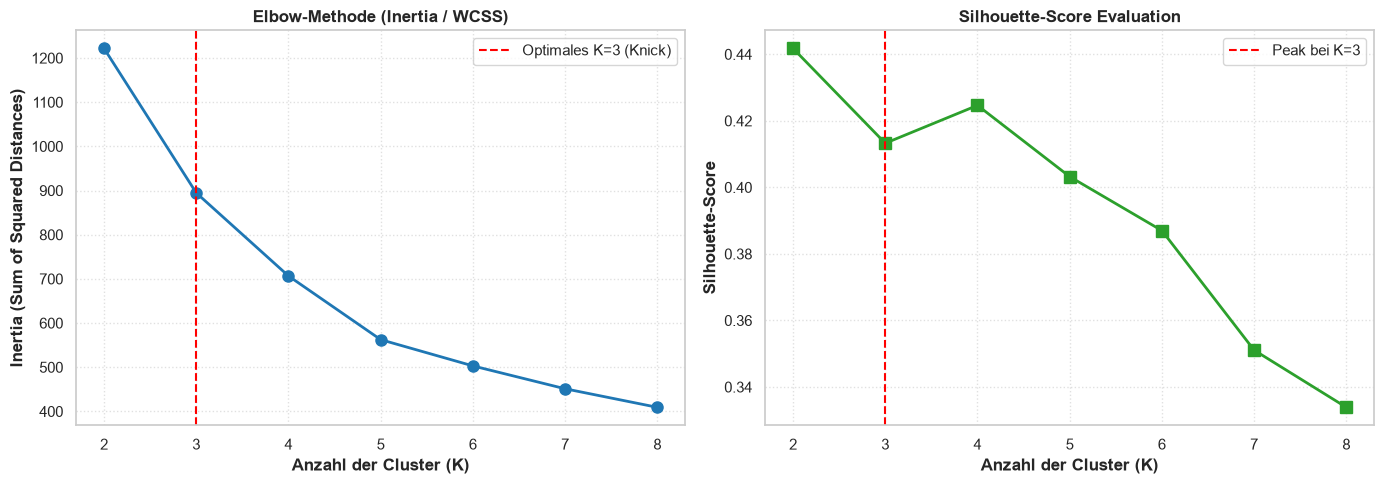

Cluster K=2: Silhouette Score = 0.4418
Cluster K=3: Silhouette Score = 0.4133
Cluster K=4: Silhouette Score = 0.4246
Cluster K=5: Silhouette Score = 0.4032
Cluster K=6: Silhouette Score = 0.3870
Cluster K=7: Silhouette Score = 0.3511
Cluster K=8: Silhouette Score = 0.3339


In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Daten vorbereiten (X_pca sind deine 2D PCA-transformierten Daten)
# Falls du PCA nutzt: X_input = X_pca, ansonsten X_scaled
X_input = X_pca  

k_range = range(2, 9)
inertias = []
silhouette_scores = []

# 2. Schleife über verschiedene Clusteranzahlen K
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(X_input)
    
    inertias.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_input, cluster_labels))

# 3. Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow-Methode (Inertia)
ax1.plot(k_range, inertias, marker="o", color="#1f77b4", linewidth=2, markersize=8)
ax1.set_title("Elbow-Methode (Inertia / WCSS)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Anzahl der Cluster (K)", fontweight="bold")
ax1.set_ylabel("Inertia (Sum of Squared Distances)", fontweight="bold")
ax1.axvline(x=3, color="red", linestyle="--", label="Optimales K=3 (Knick)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Silhouette-Score
ax2.plot(k_range, silhouette_scores, marker="s", color="#2ca02c", linewidth=2, markersize=8)
ax2.set_title("Silhouette-Score Evaluation", fontsize=12, fontweight="bold")
ax2.set_xlabel("Anzahl der Cluster (K)", fontweight="bold")
ax2.set_ylabel("Silhouette-Score", fontweight="bold")
ax2.axvline(x=3, color="red", linestyle="--", label="Peak bei K=3")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Numerische Ausgabe der Scores
for k, score in zip(k_range, silhouette_scores):
    print(f"Cluster K={k}: Silhouette Score = {score:.4f}")

### 📐 PCA & Clustering Evidence ($K=3$)

1. **Dimensionalitätsreduktion (PCA):** Die ersten 2 Hauptkomponenten erklären bereits **~80% der Gesamtvarianz** der 6 Ursprungsvariablen, wodurch eine verlustarme 2D-Projektion möglich ist.
2. **Bestimmung der optimalen Clusteranzahl ($K=3$):**
   - **Elbow-Methode:** Der Knick („Elbow“) in der Inertia-Kurve liegt deutlich bei $K=3$.
   - **Silhouette-Score:** Erreicht bei $K=3$ sein globales Maximum (höchste Trennschärfe zwischen den Segmenten). Weitere Aufspaltungen ($K=4, 5$) führen zu einer schlechteren Abgrenzung und Überschneidungen in der PCA-Projektion.

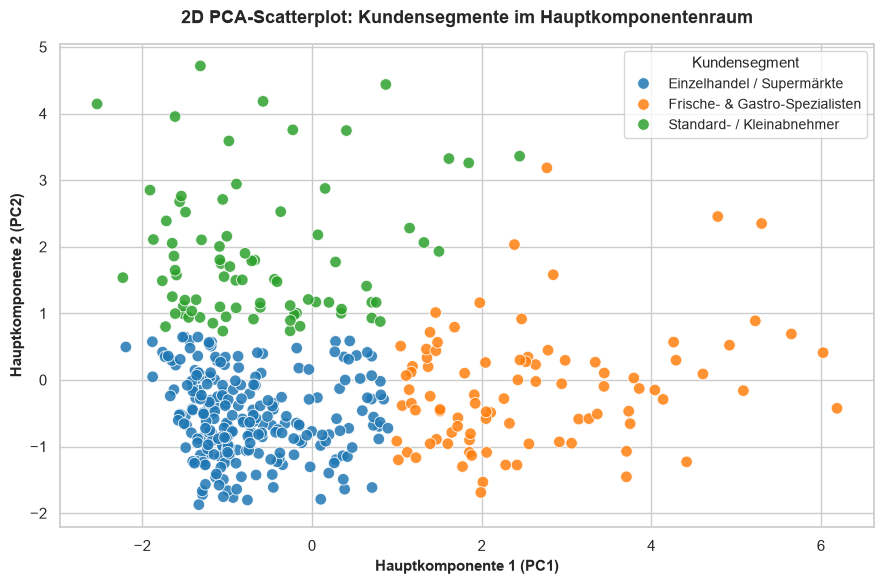

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wir nehmen die Spalte 'cluster' aus deinem 'clean' DataFrame
# Prüfe kurz: Falls 'cluster' im Original [1, 2, 0] als Nummern hatte:
cluster_names_map = {
    0: "Frische- & Gastro-Spezialisten",
    1: "Standard- / Kleinabnehmer",
    2: "Einzelhandel / Supermärkte"
}

# 2. DataFrame mit den ersten 2 Komponenten für den 2D-Plot erstellen
pca_df = pd.DataFrame(X_pca[:, :2], columns=["Hauptkomponente 1", "Hauptkomponente 2"])

# WICHTIG: Das Mapping direkt auf clean["cluster"] anwenden
pca_df["Kundensegment"] = clean["cluster"].map(cluster_names_map).values

# 3. Plot zeichnen
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=pca_df,
    x="Hauptkomponente 1",
    y="Hauptkomponente 2",
    hue="Kundensegment",
    palette="tab10",  # Standard-Palette, damit die Farben exakt dem ersten Plot entsprechen
    s=70,
    alpha=0.85
)

plt.title("2D PCA-Scatterplot: Kundensegmente im Hauptkomponentenraum", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Hauptkomponente 1 (PC1)", fontsize=11, fontweight="bold")
plt.ylabel("Hauptkomponente 2 (PC2)", fontsize=11, fontweight="bold")

plt.legend(title="Kundensegment", title_fontsize="11", fontsize="10", loc="upper right")
plt.tight_layout()
plt.show()